In [1]:
import geopandas as gpd
import pandas as pd
import osmnx as ox
import time
import numpy as np
from tqdm import tqdm, trange
from shapely.geometry import Point, MultiPoint
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.stats import pearsonr
from matplotlib_scalebar.scalebar import ScaleBar
#from shapely.ops import cascaded_union, unary_union
import utils
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
print(os.getcwd())  # 현재 작업 디렉터리 출력


/Users/jin/Downloads/2SFCA


In [3]:
parks = gpd.read_file('./data/도시숲전체_면_서울_최종_중분류.shp') # nas greenspace.shp

In [4]:
pop = pd.read_csv('./data/LOCAL_PEOPLE_20250509.csv', encoding='cp949')
pop

,"?""기준일ID""",시간대구분,행정동코드,집계구코드,총생활인구수,남자0세부터9세생활인구수,남자10세부터14세생활인구수,남자15세부터19세생활인구수,남자20세부터24세생활인구수,남자25세부터29세생활인구수,...,여자25세부터29세생활인구수,여자30세부터34세생활인구수,여자35세부터39세생활인구수,여자40세부터44세생활인구수,여자45세부터49세생활인구수,여자50세부터54세생활인구수,여자55세부터59세생활인구수,여자60세부터64세생활인구수,여자65세부터69세생활인구수,여자70세이상생활인구수
0,20250509,0,11110515,1101072010001,586.4714,29.5831,18.8504,28.6376,10.7038,15.015,...,16.9262,19.1877,18.8278,25.0539,30.7039,24.2207,23.4848,26.0297,9.8527,30.6477
1,20250509,0,11110515,1101072010002,646.7441,8.6714,5.5254,7.4187,9.9569,25.9362,...,24.6645,26.9655,42.1877,30.1979,45.7185,33.7703,26.3983,21.3674,19.7889,58.8045
2,20250509,0,11110515,1101072010003,544.3822,32.1705,20.4991,25.2295,26.3854,10.4211,...,6.7781,10.7571,30.6213,16.4315,40.6366,26.8248,18.7789,15.414,12.7254,42.2127
3,20250509,0,11110515,1101072010004,22.1353,*,*,*,*,*,...,*,*,*,*,*,*,*,*,*,*
4,20250509,0,11110515,1101072010005,230.0979,13.3169,8.4855,10.6206,10.3971,4.505,...,*,4.7695,13.9347,7.1354,16.5488,10.889,7.9717,6.7941,5.1862,17.0416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
459022,20250509,23,11740700,1125071022201,835.9834,33.851,17.0763,22.5008,11.8425,32.1117,...,33.4731,27.4596,28.2361,32.1044,53.6668,33.1693,33.3918,32.6982,25.8544,77.9975
459023,20250509,23,11740700,1125071022202,208.8763,7.2179,*,6.1149,*,8.4251,...,8.6028,6.9541,7.0286,7.7531,13.7632,8.3283,8.2746,8.2923,6.6347,20.5611
459024,20250509,23,11740700,1125071022501,862.2973,55.1454,27.8183,20.0382,17.6224,6.5735,...,29.1631,48.0979,45.5848,39.7751,49.5781,25.4719,26.0188,32.8898,15.2907,61.6968
459025,20250509,23,11740700,1125071022701,14.8689,*,*,*,*,*,...,*,*,*,*,*,*,*,*,*,*


In [5]:
pop= pop[['시간대구분','집계구코드','총생활인구수']]

In [6]:
pop

,시간대구분,집계구코드,총생활인구수
0,0,1101072010001,586.4714
1,0,1101072010002,646.7441
2,0,1101072010003,544.3822
3,0,1101072010004,22.1353
4,0,1101072010005,230.0979
...,...,...,...
459022,23,1125071022201,835.9834
459023,23,1125071022202,208.8763
459024,23,1125071022501,862.2973
459025,23,1125071022701,14.8689


In [7]:
pop['집계구코드']=pop['집계구코드'].astype(str).str[:7]

In [8]:
new_pop = pop[(pop['시간대구분'] >= 1) & (pop['시간대구분'] <= 4)]

In [9]:
new_pop.info

<bound method DataFrame.info of        시간대구분    집계구코드    총생활인구수
19095      1  1101072  580.8824
19096      1  1101072  637.2533
19097      1  1101072  549.2267
19098      1  1101072   22.8978
19099      1  1101072  227.7167
...      ...      ...       ...
95455      4  1125071  881.9419
95456      4  1125071  218.0692
95457      4  1125071  909.5007
95458      4  1125071   15.3889
95459      4  1125071  612.1995

[76365 rows x 3 columns]>

In [10]:
real_pop= new_pop.groupby('집계구코드')['총생활인구수'].mean().reset_index()

In [11]:
real_pop.head(3)

,집계구코드,총생활인구수
0,1101053,646.165247
1,1101054,819.472895
2,1101055,622.595385


In [12]:
dong =gpd.read_file('./data/통계지역경계/행정구역.shp', encoding='cp949')

In [13]:
dong

,SIDO_CD,SIDO_NM,SIGUNGU_CD,SIGUNGU_NM,ADM_CD,ADM_NM,geometry
0,11,서울특별시,11010,종로구,1101053,사직동,"POLYGON ((953553.932 1953335.741, 953555.211 1..."
1,11,서울특별시,11010,종로구,1101054,삼청동,"POLYGON ((953844.081 1955492.177, 953858.644 1..."
2,11,서울특별시,11010,종로구,1101055,부암동,"POLYGON ((952560.239 1956394.672, 952554.005 1..."
3,11,서울특별시,11010,종로구,1101056,평창동,"POLYGON ((953683.828 1959209.872, 953647.333 1..."
4,11,서울특별시,11010,종로구,1101057,무악동,"POLYGON ((952386.354 1952848.711, 952381.494 1..."
...,...,...,...,...,...,...,...
419,11,서울특별시,11250,강동구,1125070,둔촌1동,"POLYGON ((968611.972 1946736.729, 968614.219 1..."
420,11,서울특별시,11250,강동구,1125071,둔촌2동,"POLYGON ((969671.909 1948750.666, 969656.712 1..."
421,11,서울특별시,11250,강동구,1125072,암사1동,"POLYGON ((967780.213 1950660.439, 967821.733 1..."
422,11,서울특별시,11250,강동구,1125073,천호2동,"POLYGON ((966110.271 1950148.101, 966118.161 1..."


In [14]:
dong.dtypes

SIDO_CD         object
SIDO_NM         object
SIGUNGU_CD      object
SIGUNGU_NM      object
ADM_CD          object
ADM_NM          object
geometry      geometry
dtype: object

In [15]:
real_pop.dtypes

집계구코드      object
총생활인구수    float64
dtype: object

In [16]:
real_pop = real_pop.rename(columns={'집계구코드':'ADM_CD'})

In [17]:
dongs = dong.merge(real_pop, on='ADM_CD', how='left')

In [18]:
dongs.head(2)

,SIDO_CD,SIDO_NM,SIGUNGU_CD,SIGUNGU_NM,ADM_CD,ADM_NM,geometry,총생활인구수
0,11,서울특별시,11010,종로구,1101053,사직동,"POLYGON ((953553.932 1953335.741, 953555.211 1...",646.165247
1,11,서울특별시,11010,종로구,1101054,삼청동,"POLYGON ((953844.081 1955492.177, 953858.644 1...",819.472895


In [19]:
print(dongs.crs)

None


In [20]:
dongs = dongs.set_crs("epsg:5179")

In [21]:
print(dongs.crs)

epsg:5179


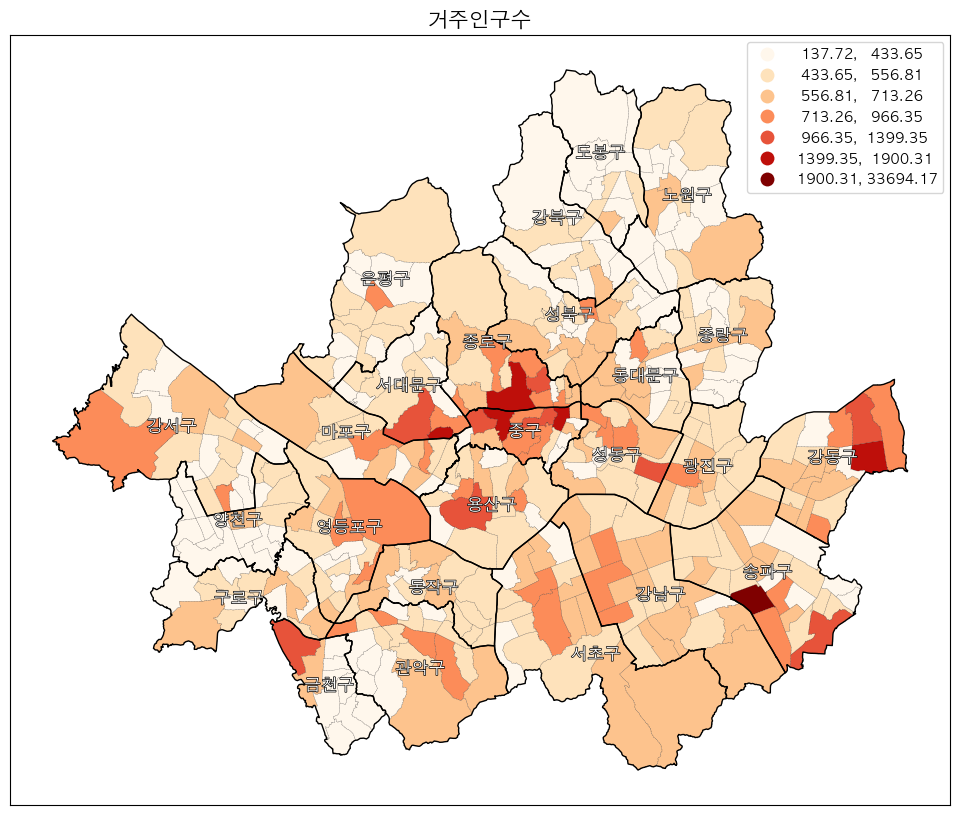

In [22]:
plt.rcParams['font.family'] = 'AppleGothic'
# 구 단위로 dissolve
# dissolve 전에 geometry 오류 정리
dongs['geometry'] = dongs['geometry'].buffer(0)
# dissolve
boroughs = dongs.dissolve(by='SIGUNGU_NM')
# dissolve 결과 geometry 오류 정리
boroughs['geometry'] = boroughs['geometry'].buffer(0.001)


fig, ax = plt.subplots(figsize=(15, 10))
dongs.plot(
    column='총생활인구수',
    ax=ax,
    legend=True,
    cmap='OrRd',
    scheme='natural_breaks',
    k=7)
dongs.boundary.plot(
    ax=ax,
    linestyle='dotted',
    lw=0.2,
    color='black',
    zorder=1
)
# # Your code here
# # 구 경계 진하게 추가
boroughs.boundary.plot(
    ax=ax,
    color='black',     # 원하는 색상(예: 'black', 'red', 'blue' 등)
    linestyle='-',
    lw=1,    # 경계선 두께(예: 2~4)
    zorder=2
)


for idx, row in boroughs.iterrows():
    ax.text(s=idx, # String to be displayed
                x=row['geometry'].centroid.coords[:][0][0], # X coordinate of label
                y=row['geometry'].centroid.coords[:][0][1], # Y coordinate of label
                fontsize=12, 
                color='white',
                path_effects=[pe.withStroke(linewidth=1, foreground="black")],
                ha='center', # Horizontal align
                va='center', # Vertical align
               )
ax.set_title(f'거주인구수', fontsize=15)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)


In [23]:
boroughs_1 = boroughs.copy()
boroughs_1 = boroughs_1.to_crs(epsg=5179)
boroughs_1['geometry'] = boroughs_1['geometry'].buffer(0.001)
boroughs_1 = boroughs_1.to_crs(epsg=4326)

In [24]:
parks = parks.to_crs("epsg:4326")
dongs = dongs.to_crs("epsg:4326")
dongs_list = ['Seoul, South Korea']

# 2. UTM-K 좌표계로 임시 변환 (격자 생성용)
from pyproj import CRS
utm_zone = 52  # 서울 기준
parks_utm = parks.to_crs(CRS(f"EPSG:326{utm_zone}"))

G = ox.graph_from_place(dongs_list, network_type='walk')
G.remove_nodes_from(list(nx.isolates(G)))

In [52]:
from shapely.geometry import box
import numpy as np
import geopandas as gpd

def create_polygon_grid(polygon, grid_size):
    """격자 생성 및 면적 계산 (미터 단위 좌표계 필수)"""
    # 경계 계산
    minx, miny, maxx, maxy = polygon.bounds
    
    # 격자 좌표 배열 (미터 단위)
    x_coords = np.arange(minx, maxx + grid_size, grid_size)
    y_coords = np.arange(miny, maxy + grid_size, grid_size)
    
    grids = []
    for x in x_coords[:-1]:  # 마지막 격자 제외
        for y in y_coords[:-1]:
            cell = box(x, y, x+grid_size, y+grid_size)
            if polygon.intersects(cell):
                intersection = polygon.intersection(cell)
                if not intersection.is_empty:
                    # 교차 영역의 실제 면적과 중심점 저장
                    grids.append({
                        'geometry': intersection.centroid,
                        'Area_grid': intersection.area
                    })
    return grids

def explode_grids(gdf, grid_size):
    """격자 분할 및 면적 정보 추가"""
    exploded = []
    for idx, row in gdf.iterrows():
        geom = row.geometry
        if geom.is_empty or not geom.is_valid:
            continue
            
        # 원본 공원 정보 추출
        original_area = row['Area']
        
        # 폴리곤 처리
        if geom.geom_type in ['Polygon', 'MultiPolygon']:
            if geom.geom_type == 'MultiPolygon':
                for poly in geom.geoms:
                    grids = create_polygon_grid(poly, grid_size)
                    for grid in grids:
                        new_row = row.copy()
                        new_row.geometry = grid['geometry']
                        new_row['Area_grid'] = grid['Area_grid']  # 그리드 면적
                        new_row['Area_total'] = original_area      # 원본 전체 면적
                        new_row['parent_id'] = idx
                        exploded.append(new_row)
            else:
                grids = create_polygon_grid(geom, grid_size)
                for grid in grids:
                    new_row = row.copy()
                    new_row.geometry = grid['geometry']
                    new_row['Area_grid'] = grid['Area_grid']
                    new_row['Area_total'] = original_area
                    new_row['parent_id'] = idx
                    exploded.append(new_row)
        else:
            # 점/선형 데이터 처리
            new_row = row.copy()
            new_row['parent_id'] = idx
            new_row['Area_grid'] = 0  # 점/선은 면적 0 처리
            new_row['Area_total'] = original_area
            exploded.append(new_row)
    
    return gpd.GeoDataFrame(exploded, crs=gdf.crs)

# 적용 예시 (UTM 좌표계 필수)
supply_utm = explode_grids(parks_utm, grid_size=200)

# WGS84 변환 (OSMnx 호환)
supply_wgs84 = supply_utm.to_crs("EPSG:4326")




In [55]:
# 원본 공원과 그리드 면적 비교
parent_0 = supply_utm[supply_utm['parent_id'] == 2000]
print(f"원본 면적: {parent_0['Area_total'].iloc[0]:.2f} m²")
print(f"그리드 합계: {parent_0['Area_grid'].sum():.2f} m²")


원본 면적: 112.70 m²
그리드 합계: 112.69 m²


In [62]:
supply_wgs84

,U2_COD,U2_NAM,Area,geometry,Area_grid,Area_total,parent_id
0,110,도시숲,27.916095,POINT (127.07116 37.43063),27.913765,27.916095,0
1,110,도시숲,427.471653,POINT (127.07038 37.43065),427.436221,427.471653,1
2,110,도시숲,807.625803,POINT (127.07073 37.4309),807.558639,807.625803,2
3,110,도시숲,246.678781,POINT (127.07029 37.43108),246.658354,246.678781,3
4,110,도시숲,80.680325,POINT (127.06995 37.43105),80.673662,80.680325,4
...,...,...,...,...,...,...,...
155038,310,가로수,196.667732,POINT (127.04901 37.6916),196.653661,196.667732,155038
155039,310,가로수,13.766157,POINT (127.04493 37.69227),13.765215,13.766157,155039
155040,310,가로수,25.741987,POINT (127.04526 37.6923),25.740219,25.741987,155040
155041,310,가로수,243.289499,POINT (127.04823 37.69297),243.272224,243.289499,155041


In [57]:
# from multiprocessing import Pool, cpu_count
# from tqdm import tqdm
# import numpy as np
# import geopandas as gpd
# from utils_parallel import process_chunk

# def parallel_processing(network, gdf, num_workers=None):
#     num_workers = num_workers or (cpu_count() - 1)
    
#     # 1. 컬럼 초기화
#     if 'nearest_osm' not in gdf.columns:
#         gdf['nearest_osm'] = None
    
#     # 2. 청크 분할
#     chunks = np.array_split(gdf, num_workers)
#     args = [(network, chunk) for chunk in chunks]
    
#     # 3. 병렬 처리
#     with Pool(num_workers) as pool:
#         results = list(tqdm(
#             pool.imap(process_chunk, args),
#             total=len(chunks),
#             desc=f"Processing {len(gdf)} features"
#         ))
    
#     # 4. 결과 병합
#     return gpd.GeoDataFrame(pd.concat(results), crs=gdf.crs)

# if __name__ == "__main__":
#     # 1. 데이터 준비
#     supply_wgs84

#     # 3. 병렬 처리 실행
#     supply = parallel_processing(G, supply_wgs84, num_workers=8)
    
#     # 4. 결과 저장
#     supply.to_file("result_final.gpkg", driver='GPKG')

from multiprocessing import Pool, cpu_count
from tqdm import tqdm
import numpy as np
import geopandas as gpd
import utils

from multiprocessing import Pool, cpu_count
from tqdm import tqdm
import numpy as np
import geopandas as gpd
import utils

def parallel_processing(network, gdf, grid_size=200, num_workers=None):
    num_workers = num_workers or (cpu_count() - 1)
    
    # 1. 필수 컬럼 확인
    assert 'Area_grid' in gdf.columns, "Area_grid 컬럼 누락"
    assert 'Area_total' in gdf.columns, "Area_total 컬럼 누락"
    
    # 2. 청크 분할 (컬럼 보장)
    chunks = [
        chunk[['geometry', 'Area_grid', 'Area_total']].copy()
        for chunk in np.array_split(gdf, num_workers)
    ]
    
    # 3. 병렬 처리
    args = [(network, chunk, grid_size) for chunk in chunks]
    with Pool(num_workers) as pool:
        results = list(tqdm(
            pool.starmap(utils.nearest_osm_enhanced, args),
            total=len(chunks),
            desc=f"Processing {len(gdf)} features"
        ))
    
    # 4. 결과 병합 (컬럼 순서 강제)
    return gpd.GeoDataFrame(
        pd.concat(results, ignore_index=True),
        crs=gdf.crs
    )[['geometry', 'Area_grid', 'Area_total', 'nearest_osm']]

if __name__ == "__main__":
    # 1. 데이터 로드 (이전 단계에서 생성된 그리드 데이터)

    # 3. 실행
    result = parallel_processing(G, supply_wgs84)
    
    # 4. 저장
    result.to_file("final_result.gpkg", driver='GPKG')


Processing 162407 features: 100%|█████████████| 9/9 [00:00<00:00, 114390.11it/s]


In [65]:
#supply_ = pd.merge(result, supply_wgs84[['Area_total', 'parent_id']], on='Area_total', how='left')
concat_wgs84= supply_wgs84['parent_id'].reset_index(drop=True)
assert len(result) ==len(concat_wgs84), "행 개수 다름"
supply__ = pd.concat([result, concat_wgs84], axis=1)
supply__

,geometry,Area_grid,Area_total,nearest_osm,parent_id
0,POINT (127.07116 37.43063),27.913765,27.916095,7168390824,0
1,POINT (127.07038 37.43065),427.436221,427.471653,7168390824,1
2,POINT (127.07073 37.4309),807.558639,807.625803,7168390824,2
3,POINT (127.07029 37.43108),246.658354,246.678781,7168390824,3
4,POINT (127.06995 37.43105),80.673662,80.680325,7168390824,4
...,...,...,...,...,...
162402,POINT (127.04901 37.6916),196.653661,196.667732,9122097163,155038
162403,POINT (127.04493 37.69227),13.765215,13.766157,10237611266,155039
162404,POINT (127.04526 37.6923),25.740219,25.741987,10237611266,155040
162405,POINT (127.04823 37.69297),243.272224,243.289499,8823891955,155041


In [69]:
import pandas as pd

# 예시: df가 결과 데이터프레임
df_check = supply__  # (당신의 데이터프레임 변수명)

# 1. parent_id별 개수 세기
parent_counts = df_check['parent_id'].value_counts()

# 2. 2개 이상인 parent_id만 추출
duplicated_ids = parent_counts[parent_counts > 1].index

# 3. 해당 parent_id만 필터링
duplicated_rows = df_check[df_check['parent_id'].isin(duplicated_ids)]

print(duplicated_rows)
print(duplicated_rows['parent_id'].value_counts())


                          geometry    Area_grid   Area_total  nearest_osm  \
99      POINT (126.96474 37.44645)     1.108712     1.461766  10577432393   
100      POINT (126.96578 37.4472)     0.353036     1.461766  10577432393   
112     POINT (126.96771 37.44833)     1.566965     1.751362    442817814   
113     POINT (126.96891 37.44885)     0.184212     1.751362    442817814   
150     POINT (126.92147 37.44967)  3457.705488  5072.818116   2618197708   
...                            ...          ...          ...          ...   
162030  POINT (127.07228 37.65713)    72.832816   851.379391   4153842184   
162396  POINT (127.04916 37.68923)   328.798424   470.396102   8573672025   
162397  POINT (127.04913 37.69046)   141.563999   470.396102   8573672025   
162398  POINT (127.04935 37.68921)   405.262532   535.658330  11823866094   
162399  POINT (127.04932 37.69044)   130.357270   535.658330  11823866094   

        parent_id  
99            100  
100           100  
112           1

In [70]:
demand= utils.nearest_osm(G, dongs)

100%|█████████████████████████████████████████| 424/424 [00:59<00:00,  7.13it/s]


In [42]:
# import ast

# supply['nearest_osm'] = supply['nearest_osm'].apply(lambda x: float(ast.literal_eval(x)[0]) if isinstance(x, str) else float(x[0]))

# supply

,U2_COD,U2_NAM,Area,nearest_osm,geometry
0,110,도시숲,27.916095,7.168391e+09,"POLYGON ((127.07118 37.43062, 127.07112 37.430..."
1,110,도시숲,427.471653,7.168391e+09,"POLYGON ((127.07047 37.43073, 127.07066 37.430..."
2,110,도시숲,807.625803,7.168391e+09,"POLYGON ((127.07086 37.43108, 127.07086 37.431..."
3,110,도시숲,246.678781,7.168391e+09,"POLYGON ((127.07035 37.431, 127.07033 37.431, ..."
4,110,도시숲,80.680325,7.168391e+09,"POLYGON ((127.07016 37.43095, 127.07015 37.430..."
...,...,...,...,...,...
19375,310,가로수,196.667732,9.122097e+09,"POLYGON ((127.04928 37.69094, 127.04926 37.690..."
19376,310,가로수,13.766157,1.023761e+10,"POLYGON ((127.04494 37.69224, 127.04492 37.692..."
19377,310,가로수,25.741987,1.023761e+10,"POLYGON ((127.04528 37.69225, 127.04526 37.692..."
19378,310,가로수,243.289499,8.823892e+09,"POLYGON ((127.04842 37.69235, 127.0484 37.6923..."


In [71]:
nodes, edges = ox.graph_to_gdfs(G, nodes = True, edges = True, node_geometry = True)

In [72]:
G = utils.network_settings_walk(G)

walk network set done


In [73]:
nodes, edges = ox.graph_to_gdfs(G, nodes=True, edges=True, node_geometry=True)

In [74]:
weights = {5:1, 15:0.68, 30:0.22}  # keys: time, values: weight
import numpy as np
def corrected_step1(
    weights,
    supply_grid: gpd.GeoDataFrame,  # 그리드 분할된 공급 데이터
    supply_attr: str,
    demand: gpd.GeoDataFrame,
    demand_attr: str,
    network: nx.MultiDiGraph
):
    supply_grid['ratio'] = 0

    for i in tqdm(range(supply_grid.shape[0])):
        total_demand = 0
        prev_nodes = set()
        
        # 각 그리드의 중심 노드 사용
        grid_node = supply_grid.loc[i, 'nearest_osm']
        
        for time, weight in sorted(weights.items()):
            temp_nodes = nx.single_source_dijkstra_path_length(
                network, grid_node, cutoff=time, weight='time'
            ).keys()
            
            current_nodes = set(temp_nodes) - prev_nodes
            demand_sum = demand.loc[
                demand['nearest_osm'].isin(current_nodes), demand_attr
            ].sum() * weight
            
            total_demand += demand_sum
            prev_nodes.update(temp_nodes)
        
        # 그리드별 공급값 분할 적용 (예: 면적 비율)
        grid_area = supply_grid.loc[i, supply_attr]
        park_total_area = supply_grid.loc[
            supply_grid['parent_id'] == supply_grid.loc[i, 'parent_id'], 
            supply_attr
        ].sum()
        
        supply_value = grid_area / park_total_area * supply_grid.loc[i, 'Area_total']
        supply_grid.loc[i, 'ratio'] = (supply_value / total_demand * 100000) if total_demand > 0 else 0

    return supply_grid


result_step1 = corrected_step1(weights, supply__, 'Area_grid', demand, '총생활인구수', G)

100%|██████████████████████████████████| 162407/162407 [18:18<00:00, 147.78it/s]


In [123]:
result_step1

,U2_COD,U2_NAM,Area,geometry,nearest_osm,parent_id,ratio
0,110,도시숲,27.916095,POINT (127.07116 37.43063),[7168390824],0,19940.862650
1,110,도시숲,427.471653,POINT (127.07038 37.43065),[7168390824],1,28972.120884
2,110,도시숲,807.625803,POINT (127.07073 37.4309),[7168390824],2,24143.088452
3,110,도시숲,246.678781,POINT (127.07029 37.43108),[7168390824],3,124.299514
4,110,도시숲,80.680325,POINT (127.06995 37.43105),[7168390824],4,726.126790
...,...,...,...,...,...,...,...
20295,310,가로수,196.667732,POINT (127.04901 37.6916),[9122097163],155038,60471.204279
20296,310,가로수,13.766157,POINT (127.04493 37.69227),[10237611266],155039,4232.804519
20297,310,가로수,25.741987,POINT (127.04526 37.6923),[10237611266],155040,7915.121282
20298,310,가로수,243.289499,POINT (127.04823 37.69297),[8823891955],155041,74806.420175


In [75]:
def corrected_step2(
    weights,
    result_step1: gpd.GeoDataFrame,
    demand: gpd.GeoDataFrame,
    network: nx.MultiDiGraph
) -> gpd.GeoDataFrame:
    """
    개선된 2단계: 그리드 단위 정밀 계산
    """
    demand_ = demand.copy()
    demand_['access'] = 0.0

    # 공급 그리드 데이터 준비
    supply_grids = result_step1[['nearest_osm', 'ratio']].copy()

    for z in tqdm(range(demand_.shape[0]), desc="Processing demand points"):
        total_access = 0.0
        prev_nodes = set()
        demand_node = demand_.loc[z, 'nearest_osm']

        for time, weight in sorted(weights.items()):
            # 현재 시간 임계값까지의 모든 노드 탐색
            current_nodes = set(nx.single_source_dijkstra_path_length(
                network, demand_node, cutoff=time, weight='time'
            ).keys()) - prev_nodes

            # 현재 구간 내 공급 그리드 필터링
            filtered = supply_grids[supply_grids['nearest_osm'].isin(current_nodes)]
            total_access += filtered['ratio'].sum() * weight

            prev_nodes.update(current_nodes)

        demand_.loc[z, 'access'] = total_access

    return demand_


result_step2 = corrected_step2(
    weights=weights,
    result_step1=result_step1,
    demand=demand,
    network=G
)

Processing demand points: 100%|███████████████| 424/424 [00:08<00:00, 49.89it/s]


In [76]:
result_step2

,SIDO_CD,SIDO_NM,SIGUNGU_CD,SIGUNGU_NM,ADM_CD,ADM_NM,geometry,총생활인구수,nearest_osm,access
0,11,서울특별시,11010,종로구,1101053,사직동,"POLYGON ((126.97399 37.57823, 126.974 37.57809...",646.165247,2.304578e+09,3.869731e+07
1,11,서울특별시,11010,종로구,1101054,삼청동,"POLYGON ((126.97714 37.59768, 126.9773 37.5976...",819.472895,4.198106e+09,4.753468e+07
2,11,서울특별시,11010,종로구,1101055,부암동,"POLYGON ((126.96253 37.60575, 126.96246 37.605...",622.595385,4.368693e+08,2.129410e+08
3,11,서울특별시,11010,종로구,1101056,평창동,"POLYGON ((126.97508 37.63118, 126.97468 37.629...",541.615290,2.303508e+09,1.440954e+08
4,11,서울특별시,11010,종로구,1101057,무악동,"POLYGON ((126.96079 37.57378, 126.96074 37.573...",389.776531,3.096779e+09,3.159047e+07
...,...,...,...,...,...,...,...,...,...,...
419,11,서울특별시,11250,강동구,1125070,둔촌1동,"POLYGON ((127.1448 37.51939, 127.14483 37.5192...",838.039244,1.245110e+10,4.491204e+07
420,11,서울특별시,11250,강동구,1125071,둔촌2동,"POLYGON ((127.15671 37.53758, 127.15654 37.537...",487.941971,5.273883e+09,4.336631e+07
421,11,서울특별시,11250,강동구,1125072,암사1동,"POLYGON ((127.13522 37.55473, 127.13569 37.554...",463.037580,4.194375e+09,2.753742e+07
422,11,서울특별시,11250,강동구,1125073,천호2동,"POLYGON ((127.11633 37.55005, 127.11642 37.550...",696.772748,3.844539e+09,2.602385e+07


In [77]:
result_step2_nor = result_step2.copy(deep=True)


min_sum = result_step2_nor['access'].min()
max_sum = result_step2_nor['access'].max()
# if 문을 통해 반복을 돌린다. 이를 하지 않았더니 똑같은 값만 나왔었다.
if max_sum == min_sum:
    print('틀렸다')
else:
    result_step2_nor['access_normalized'] = (result_step2_nor['access'] - min_sum) / (max_sum - min_sum)

In [78]:
result_step2_nor

,SIDO_CD,SIDO_NM,SIGUNGU_CD,SIGUNGU_NM,ADM_CD,ADM_NM,geometry,총생활인구수,nearest_osm,access,access_normalized
0,11,서울특별시,11010,종로구,1101053,사직동,"POLYGON ((126.97399 37.57823, 126.974 37.57809...",646.165247,2.304578e+09,3.869731e+07,0.098809
1,11,서울특별시,11010,종로구,1101054,삼청동,"POLYGON ((126.97714 37.59768, 126.9773 37.5976...",819.472895,4.198106e+09,4.753468e+07,0.122743
2,11,서울특별시,11010,종로구,1101055,부암동,"POLYGON ((126.96253 37.60575, 126.96246 37.605...",622.595385,4.368693e+08,2.129410e+08,0.570707
3,11,서울특별시,11010,종로구,1101056,평창동,"POLYGON ((126.97508 37.63118, 126.97468 37.629...",541.615290,2.303508e+09,1.440954e+08,0.384255
4,11,서울특별시,11010,종로구,1101057,무악동,"POLYGON ((126.96079 37.57378, 126.96074 37.573...",389.776531,3.096779e+09,3.159047e+07,0.079562
...,...,...,...,...,...,...,...,...,...,...,...
419,11,서울특별시,11250,강동구,1125070,둔촌1동,"POLYGON ((127.1448 37.51939, 127.14483 37.5192...",838.039244,1.245110e+10,4.491204e+07,0.115640
420,11,서울특별시,11250,강동구,1125071,둔촌2동,"POLYGON ((127.15671 37.53758, 127.15654 37.537...",487.941971,5.273883e+09,4.336631e+07,0.111454
421,11,서울특별시,11250,강동구,1125072,암사1동,"POLYGON ((127.13522 37.55473, 127.13569 37.554...",463.037580,4.194375e+09,2.753742e+07,0.068585
422,11,서울특별시,11250,강동구,1125073,천호2동,"POLYGON ((127.11633 37.55005, 127.11642 37.550...",696.772748,3.844539e+09,2.602385e+07,0.064486


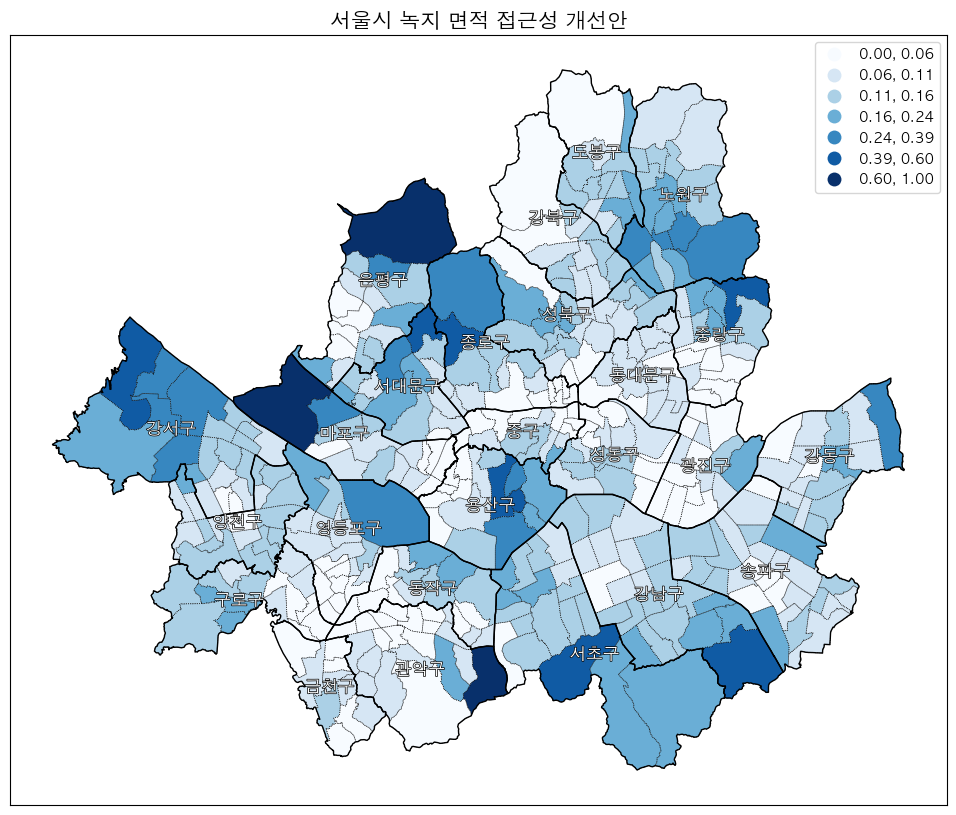

In [80]:
fig, ax = plt.subplots(figsize=(15, 10))

# 구 단위로 dissolve
# dissolve 전에 geometry 오류 정리
result_step2_nor['geometry'] = result_step2_nor['geometry'].buffer(0)
# dissolve
boroughs = result_step2_nor.dissolve(by='SIGUNGU_NM')

boroughs_1 = boroughs.copy()
boroughs_1 = boroughs_1.to_crs(epsg=5179)
boroughs_1['geometry'] = boroughs_1['geometry'].buffer(0.001)
boroughs_1 = boroughs_1.to_crs(epsg=4326)


# 첫 번째 지도: demand_
result_step2_nor.plot(
    column='access_normalized',
    ax=ax,
    legend=True,
    cmap='Blues',
    scheme='naturalbreaks',
    k=7
)
result_step2_nor.boundary.plot(
    ax=ax,
    linestyle='dotted',
    lw=0.5,
    color='black',
    zorder=1
)

boroughs_1.boundary.plot(
    ax=ax,
    color='black',     # 원하는 색상(예: 'black', 'red', 'blue' 등)
    linestyle='-',
    lw=1,    # 경계선 두께(예: 2~4)
    zorder=2
)
for idx, row in boroughs_1.iterrows():
    ax.text(s=idx, # String to be displayed
                x=row['geometry'].centroid.coords[:][0][0], # X coordinate of label
                y=row['geometry'].centroid.coords[:][0][1], # Y coordinate of label
                fontsize=12, 
                color='white',
                path_effects=[pe.withStroke(linewidth=1, foreground="black")],
                ha='center', # Horizontal align
                va='center', # Vertical align
               )
ax.set_title(f'서울시 녹지 면적 접근성 개선안', fontsize=15)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)


# scalebar = ScaleBar(dx=1, units="m", location='lower right')  # dx=1은 좌표계가 미터 단위일 때
# ax.add_artist(scalebar)

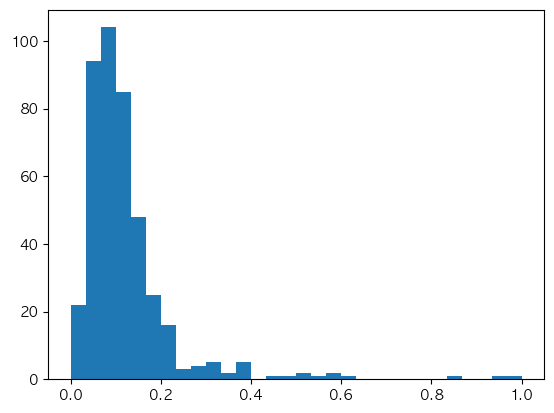

In [81]:
import matplotlib.pyplot as plt
plt.hist(result_step2_nor['access_normalized'], bins=30)  # 히스토그램으로 분포 확인
plt.show()

In [82]:
dongs['총생활인구수'].describe()

count      424.000000
mean       619.669536
std       1624.237038
min        137.723546
25%        407.831778
50%        496.043481
75%        600.462766
max      33694.172275
Name: 총생활인구수, dtype: float64

In [83]:
max_idx = dongs['총생활인구수'].idxmax()
dongs.loc[max_idx]

SIDO_CD                                                       11
SIDO_NM                                                    서울특별시
SIGUNGU_CD                                                 11240
SIGUNGU_NM                                                   송파구
ADM_CD                                                   1124066
ADM_NM                                                      가락1동
geometry       POLYGON ((127.1101515247529 37.50051059492555,...
총생활인구수                                              33694.172275
nearest_osm                                         2911195456.0
Name: 394, dtype: object

In [84]:
min_idx = dongs['총생활인구수'].idxmin()
dongs.loc[min_idx]

SIDO_CD                                                       11
SIDO_NM                                                    서울특별시
SIGUNGU_CD                                                 11220
SIGUNGU_NM                                                   서초구
ADM_CD                                                   1122056
ADM_NM                                                      반포본동
geometry       POLYGON ((126.99222812629364 37.50663133440654...
총생활인구수                                                137.723546
nearest_osm                                        10124068123.0
Name: 344, dtype: object

In [85]:
result_step2_nor.to_file("./진짜최종_도보_30min_grid.shp", driver="ESRI Shapefile")


In [88]:
result_step2_nor.to_csv("./진짜최종_도보_30min_grid.csv", encoding="utf-8", index=False)


In [91]:
result_step2_nor.to_file("./진짜최종_도보_30min_grid.gpkg", driver="GPKG")

supply__.to_file("./진짜최종_nearest_osm.gpkg", driver="GPKG")


그리드 기반 Moran's I (거리 기반):
Moran's I: 0.207
P-value: 0.00100


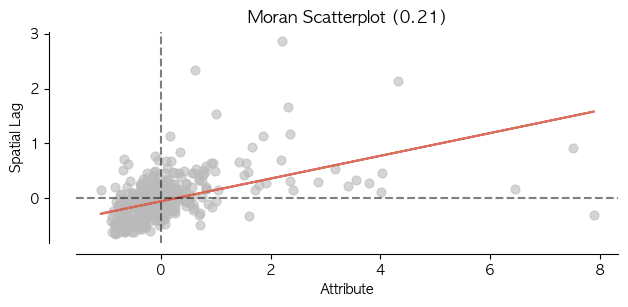

그리드 기반 Moran's I (거리 기반):
Moran's I: 0.193
P-value: 0.00100


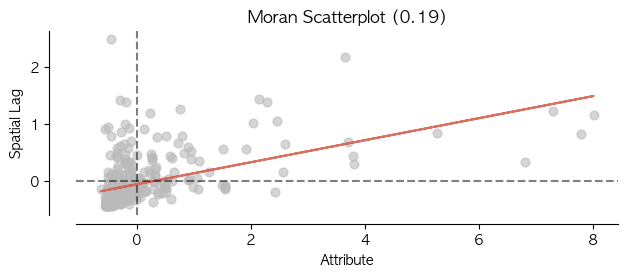


그리드 기반 LISA 분석 (거리 기반):


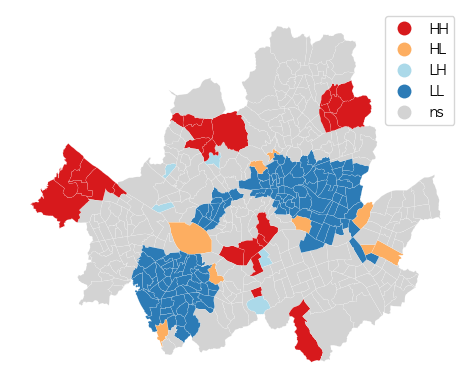


그리드 기반 LISA 분석 (거리 기반):


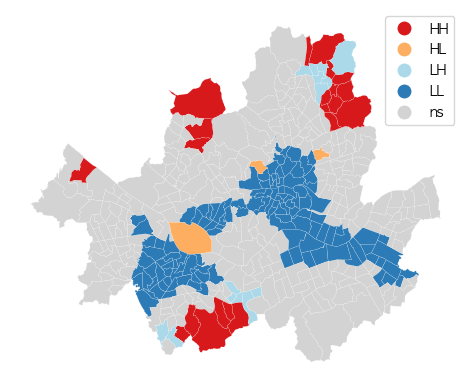


Gini 계수 - 그리드: 0.360, 중심점: 0.509

KS 검정 결과: 통계량=0.167, p-value=0.00001


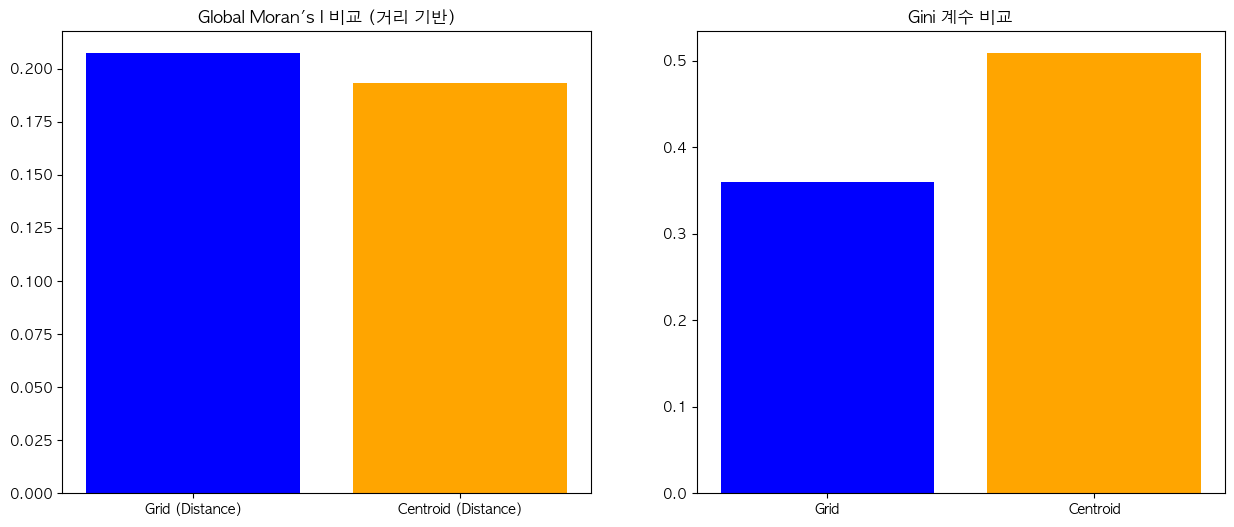

In [93]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from esda.moran import Moran, Moran_Local
from splot.esda import moran_scatterplot, plot_moran, lisa_cluster
from scipy.stats import ks_2samp
import libpysal

# 1. 데이터 준비
grid_access = gpd.read_file('진짜최종_도보_30min_grid.gpkg')
centroid_access = gpd.read_file('진짜최종_도보_30min_centroid.gpkg')

# 2. 좌표계 변환 (UTM-K: EPSG 5179)
grid_access_utm = grid_access.to_crs(epsg=5179)
centroid_access_utm = centroid_access.to_crs(epsg=5179)

# 3. 거리 기반 공간 가중치 생성 (3km 기준)
w_distance = libpysal.weights.DistanceBand.from_dataframe(
    grid_access_utm, 
    threshold=3000,  # 3km (미터 단위)
    binary=False,     # 거리 감쇠 적용
    alpha=-0.1,       # 감쇠 계수
    geom_col='geometry'
)
w_distance.transform = 'r'  # 행 표준화

# 4. Global Moran's I 계산 함수 업데이트
def calculate_moran(access_data, w):
    moran = Moran(access_data['access'].values, w)
    print(f"Moran's I: {moran.I:.3f}")
    print(f"P-value: {moran.p_sim:.5f}")
    
    # Moran 플롯
    fig, ax = moran_scatterplot(moran, aspect_equal=True)
    plt.show()
    return moran

print("그리드 기반 Moran's I (거리 기반):")
moran_grid = calculate_moran(grid_access_utm, w_distance)
print("그리드 기반 Moran's I (거리 기반):")
moran_centroid = calculate_moran(centroid_access_utm, w_distance)

# 5. LISA 분석 함수 업데이트
def calculate_lisa(access_data, w):
    moran_loc = Moran_Local(access_data['access'].values, w)
    
    # LISA 클러스터 맵
    fig, ax = lisa_cluster(moran_loc, access_data)
    plt.show()
    return moran_loc

print("\n그리드 기반 LISA 분석 (거리 기반):")
lisa_grid = calculate_lisa(grid_access_utm, w_distance)
print("\n그리드 기반 LISA 분석 (거리 기반):")
lisa_moran = calculate_lisa(centroid_access_utm, w_distance)

# 6. Gini 계수 계산 (기존 코드 유지)
def gini(array):
    array = array.flatten()
    array += 1e-10
    array = np.sort(array)
    n = len(array)
    index = np.arange(1, n+1)
    return (np.sum((2 * index - n - 1) * array)) / (n * np.sum(array))

gini_grid = gini(grid_access['access'].values)
gini_centroid = gini(centroid_access['access'].values)
print(f"\nGini 계수 - 그리드: {gini_grid:.3f}, 중심점: {gini_centroid:.3f}")

# 7. Kolmogorov-Smirnov 검정 (기존 코드 유지)
ks_stat, ks_p = ks_2samp(grid_access['access'], centroid_access['access'])
print(f"\nKS 검정 결과: 통계량={ks_stat:.3f}, p-value={ks_p:.5f}")

# 8. 시각화 업데이트
fig, ax = plt.subplots(1,2, figsize=(15,6))

# Moran's I 비교
ax[0].bar(['Grid (Distance)', 'Centroid (Distance)'], 
          [moran_grid.I, moran_centroid.I],
          color=['blue', 'orange'])
ax[0].set_title("Global Moran's I 비교 (거리 기반)")

# Gini 계수 비교
ax[1].bar(['Grid', 'Centroid'],
          [gini_grid, gini_centroid],
          color=['blue', 'orange'])
ax[1].set_title("Gini 계수 비교")

plt.show()


In [108]:
!pip install splot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 11.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.2/26.2 MB 11.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 11.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [splot]32m6/9 [spreg]n]]
